In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("NetFlix.csv")

In [39]:
df = df.dropna(subset=['type', 'release_year'])


In [42]:
genre_series = df['type'].dropna().str.split(', ').explode()
genre_count = genre_series.value_counts()


In [43]:
print("\nTop 10 Genres")
print(genre_count.head(10))

print("\nBottom 10 Genres")
print(genre_count.tail(10))

print("\nMost Popular Genre")
print(genre_count.idxmax(), "-", genre_count.max())

print("\nLeast Popular Genre")
print(genre_count.idxmin(), "-", genre_count.min())


Top 10 Genres
type
Movie      5377
TV Show    2410
Name: count, dtype: int64

Bottom 10 Genres
type
Movie      5377
TV Show    2410
Name: count, dtype: int64

Most Popular Genre
Movie - 5377

Least Popular Genre
TV Show - 2410


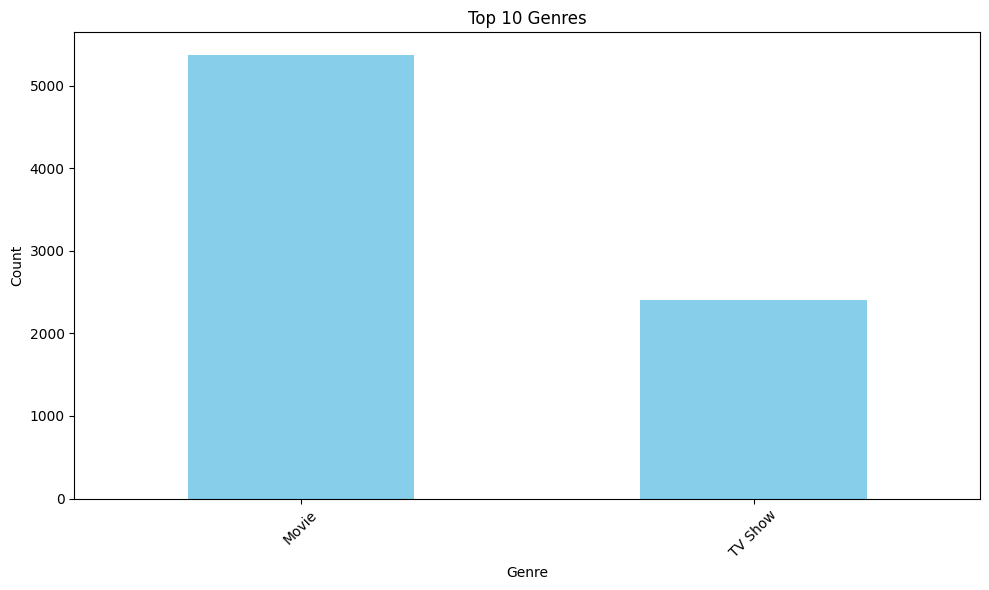

In [44]:
plt.figure(figsize=(10,6))
genre_count.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
movies = df[df['type']=="Movie"]
tvshows = df[df['type']=="TV Show"]

oldest_movie = movies.loc[movies['release_year'].idxmin()]
newest_movie = movies.loc[movies['release_year'].idxmax()]

oldest_tv = tvshows.loc[tvshows['release_year'].idxmin()]
newest_tv = tvshows.loc[tvshows['release_year'].idxmax()]


In [47]:
print("\nOldest Movie")
print(oldest_movie)

print("\nNewest Movie")
print(newest_movie)

print("\nOldest TV Show")
print(oldest_tv)

print("\nNewest TV Show")
print(newest_tv)


Oldest Movie
show_id                                                     s4961
type                                                        Movie
title                                              Prelude to War
director                                              Frank Capra
cast                                                          NaN
country                                             United States
date_added                                              31-Mar-17
release_year                                                 1942
rating                                                      TV-14
duration                                                       52
genres                              Classic Movies, Documentaries
description     Frank Capra's documentary chronicles the rise ...
Name: 4402, dtype: object

Newest Movie
show_id                                                     s1286
type                                                        Movie
title                 

In [48]:
country_series = df['country'].dropna().str.split(', ').explode()

country_count = country_series.value_counts()

In [49]:
print("\nCountry with Highest Netflix Content")
print(country_count.idxmax(), "-", country_count.max())

print("\nTop 10 Countries")
print(country_count.head(10))

print("\nBottom 10 Countries")
print(country_count.tail(10))


Country with Highest Netflix Content
United States - 3296

Top 10 Countries
country
United States     3296
India              990
United Kingdom     722
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

Bottom 10 Countries
country
Somalia            1
Sudan              1
Panama             1
Armenia            1
Mongolia           1
United Kingdom,    1
Uganda             1
East Germany       1
Montenegro         1
Syria              1
Name: count, dtype: int64


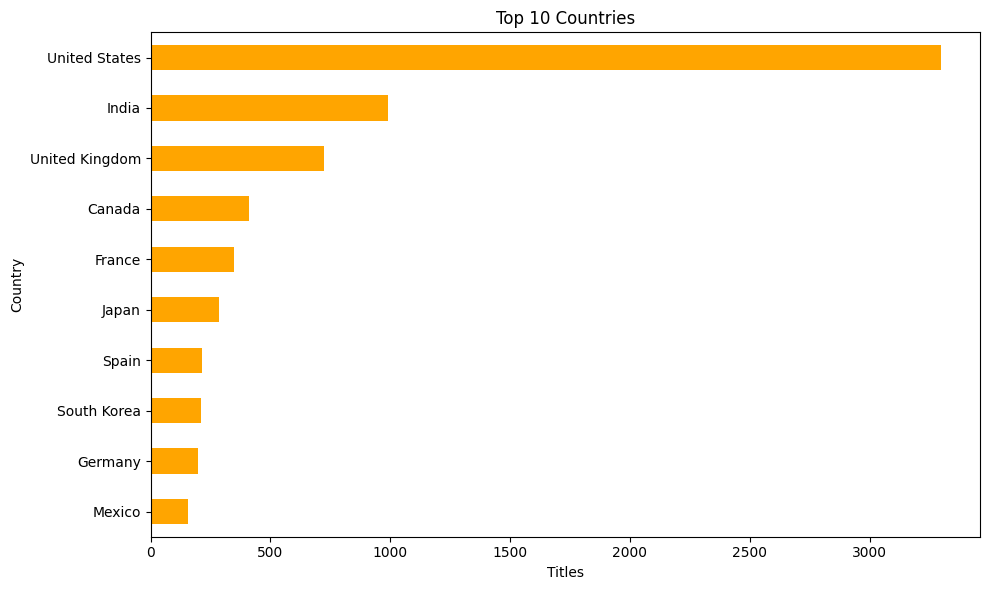

In [50]:
plt.figure(figsize=(10,6))
country_count.head(10).sort_values().plot(kind='barh', color='orange')
plt.title("Top 10 Countries")
plt.xlabel("Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [51]:
movie_directors = movies['director'].dropna().str.split(', ').explode()
movie_director_count = movie_directors.value_counts()

tv_directors = tvshows['director'].dropna().str.split(', ').explode()
tv_director_count = tv_directors.value_counts()

In [52]:
print("\nDirector with Highest Movies")
print(movie_director_count.idxmax(), "-", movie_director_count.max())

print("\nDirector with Highest TV Shows")
print(tv_director_count.idxmax(), "-", tv_director_count.max())


Director with Highest Movies
Jan Suter - 21

Director with Highest TV Shows
Alastair Fothergill - 3


In [53]:
director_count = df['director'].dropna().str.split(', ').explode().value_counts()


In [54]:
print("\nTop 10 Directors")
print(director_count.head(10))


Top 10 Directors
director
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Steven Spielberg       10
Anurag Kashyap          9
Name: count, dtype: int64


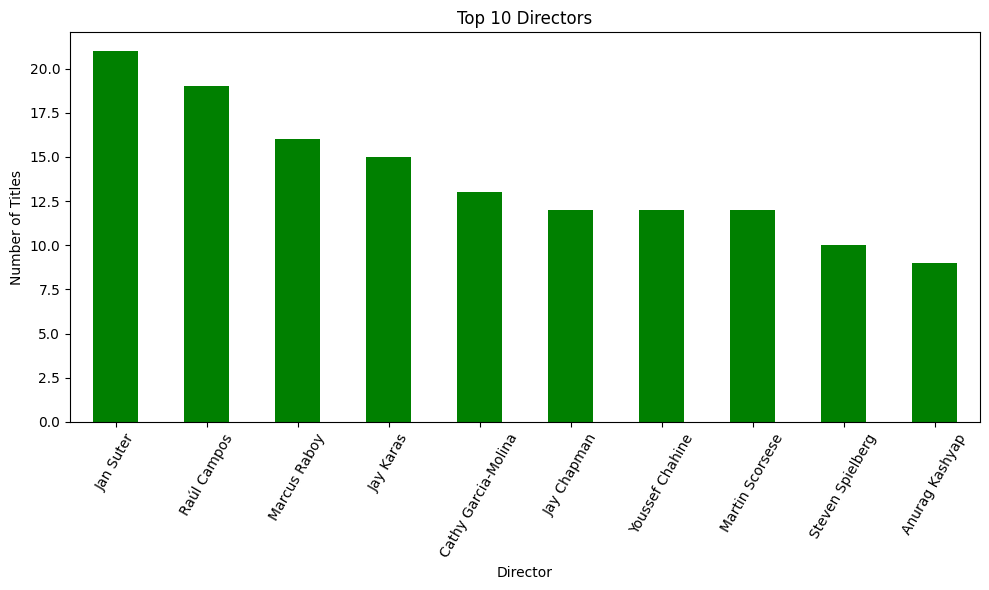

In [55]:
plt.figure(figsize=(10,6))
director_count.head(10).plot(kind='bar', color='green')
plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


In [56]:
before_2020 = len(df[df['release_year'] < 2020])
during_2020 = len(df[df['release_year'] == 2020])
after_2020 = len(df[df['release_year'] > 2020])

release_data = {
    "Before 2020": before_2020,
    "During 2020": during_2020,
    "After 2020": after_2020
}

In [57]:
print(release_data)

{'Before 2020': 6888, 'During 2020': 868, 'After 2020': 31}


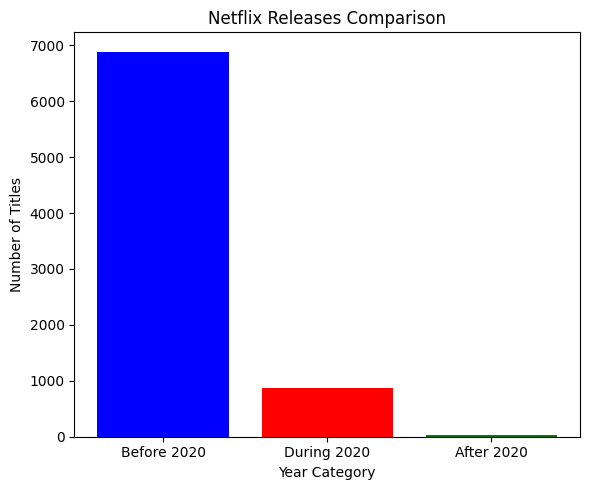

In [58]:


plt.figure(figsize=(6,5))
plt.bar(release_data.keys(), release_data.values(), color=['blue','red','green'])
plt.title("Netflix Releases Comparison")
plt.xlabel("Year Category")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()